# Model 3 - Decision Tree

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)

In [3]:
df = pd.read_csv(r"./datasets/Heart_Disease_Indicators.csv")

In [4]:
X = df.drop(["HeartDiseaseorAttack"], axis=1)
y = df["HeartDiseaseorAttack"]

In [5]:
feature_cols = [c for c in df.columns if c != "HeartDiseaseorAttack"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

# Training with Gini Index

In [7]:
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=100,
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=50,
)

In [8]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,50
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

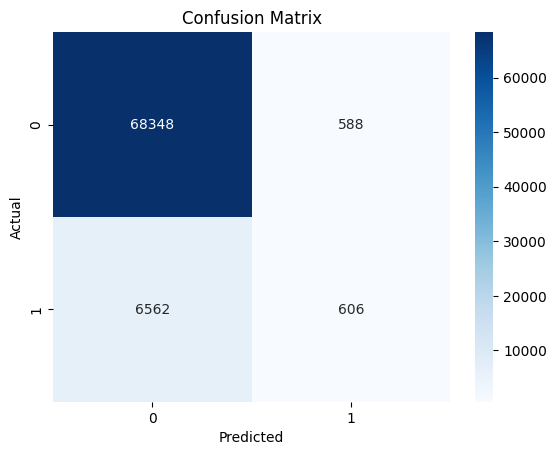

In [10]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     68936
         1.0       0.51      0.08      0.14      7168

    accuracy                           0.91     76104
   macro avg       0.71      0.54      0.55     76104
weighted avg       0.87      0.91      0.87     76104



In [12]:
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

Test ROC-AUC: 0.7908006333951444


# Pickle File

In [13]:
with open('./model-3.pkl', 'wb') as f:
    pickle.dump(model, f)

In [14]:
with open('./model-3.pkl', 'rb') as f:
    loaded_model = pickle.load(f)